# Titanic - Machine Learning from Disaster

The competition is simple: use machine learning to create a model that predicts which passengers survived the Titanic shipwreck.


**The Challenge**

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

## Data Dictionary

| Variable | Definition | Key |
|----------|------------|-----|
| survival | Survival   | 0 = No, 1 = Yes |
| pclass   | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| sex      | Sex        | |
| Age      | Age in years | |
| sibsp    | # of siblings / spouses aboard the Titanic | |
| parch    | # of parents / children aboard the Titanic | |
| ticket   | Ticket number | |
| fare     | Passenger fare | |
| cabin    | Cabin number | |
| embarked | Port of Embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |

### Variable Notes

- **pclass**: A proxy for socio-economic status (SES)  
  1st = Upper  
  2nd = Middle  
  3rd = Lower

- **age**: Age is fractional if less than 1. If the age is estimated, it is in the form of xx.5

- **sibsp**: The dataset defines family relations in this way...  
  Sibling = brother, sister, stepbrother, stepsister  
  Spouse = husband, wife (mistresses and fiancés were ignored)

- **parch**: The dataset defines family relations in this way...  
  Parent = mother, father  
  Child = daughter, son, stepdaughter, stepson  
  Some children travelled only with a nanny, therefore parch=0 for them.

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import phik
from numpy.random import RandomState
sns.set()

import sklearn
import lightgbm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler, 
    MinMaxScaler,
    RobustScaler,
    OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV 
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

# Fixing random state and test size
RANDOM_STATE = 42
TEST_SIZE = 0.25
state = RandomState(12345)

sklearn.__version__, lightgbm.__version__


('1.4.2', '4.3.0')

# Data overview

In [5]:
# Uploading files
pth_train = '../data/train.csv'
pth_test = '../data/test.csv'
    
if os.path.exists(pth_train):
    train_df = pd.read_csv(pth_train)
    test_df = pd.read_csv(pth_test)
else:
    print('Something is wrong')

In [6]:
# General info function
def general_info(df):
    df.info(), display(df.shape, df.head())

In [7]:
# Let's look at the train dataset
general_info(train_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


(891, 12)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


There are 891 passengers with 12 features, missing values in the `Age`,`Cabin` and `Embarked` columns.

In [8]:
# Let's look at the test dataset
general_info(test_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


(418, 11)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


The test dataset is half the size of the training dataset. There are missing values in the `Age`,`Cabin` and `Embarked` columns.

# EDA 

## Statistical analysis of numerical features

In [9]:
# Visualize missing values
pd.DataFrame(round(train_df.select_dtypes(include='number').isna().mean()*100,),).style.background_gradient('coolwarm')

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Age,20.000000
SibSp,0.000000
Parch,0.000000
Fare,0.000000


We see that the Age feature has 20 % missing values; after the analysis, we’ll fill them in.

In [10]:
# Calculate the statistics for the quantitative features.
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


The minimum age on the Titanic is 0.42 and the maximum is 80 — this is acceptable and not an anomaly. The minimum ticket price is 0, meaning someone travelled for free.

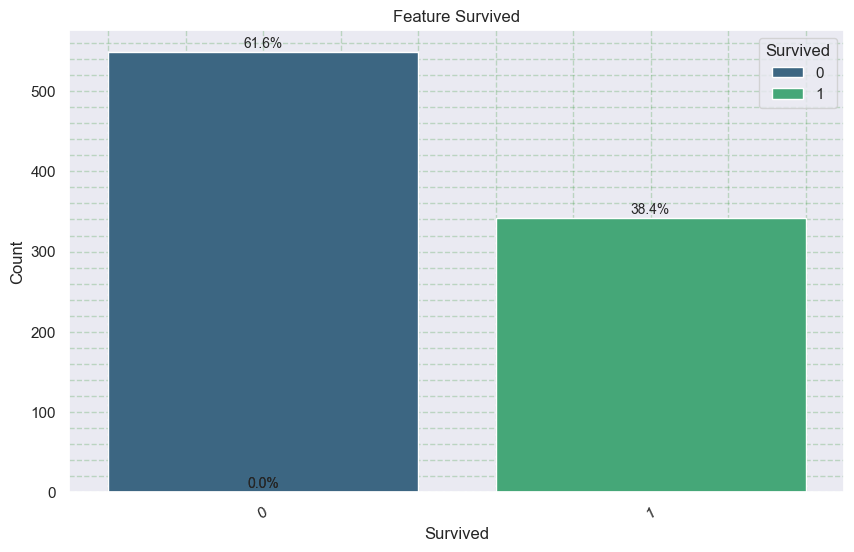

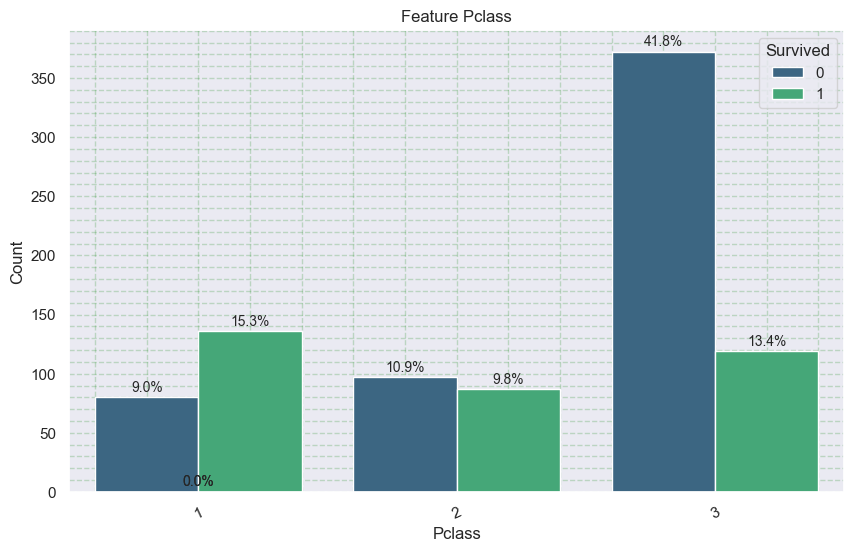

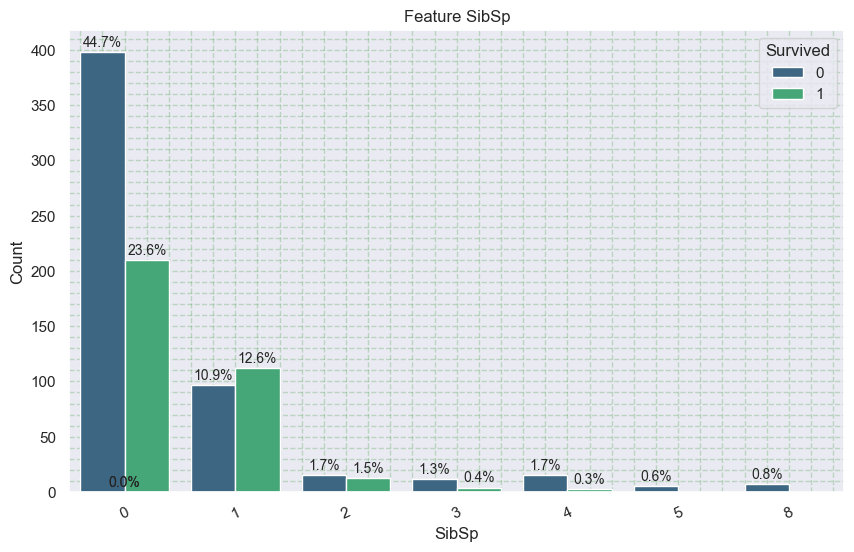

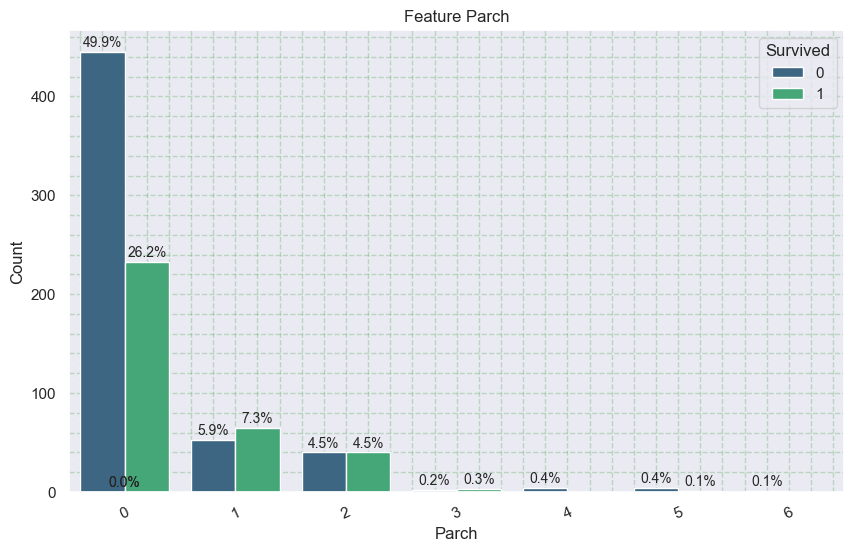

In [11]:
# Plotting the countlot for discrete features
for col in train_df[['Survived', 'Pclass', 'SibSp', 'Parch']].columns:
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(x=col, data=train_df, hue='Survived', palette='viridis', legend=True)
    total = len(train_df)
    for p in ax.patches:
        percentage = 100 * p.get_height() / total
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 5, 
                f'{percentage:.1f}%', ha='center', fontsize=10)
    plt.grid(True, linestyle='--', color='green', alpha=0.2, which='both')
    plt.minorticks_on()
    plt.tick_params(which='minor')
    plt.xticks(rotation=25)
    plt.title(f'Feature {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

The survival vs non‑survival ratio stands at 40:60, indicating a moderately imbalanced target variable; we’ll revisit class imbalance strategies later.

Third‑class passengers dominate the dataset, reflecting the historical socioeconomic distribution on the Titanic.

Most passengers have zero spouses/siblings and zero parents/children, suggesting a large proportion travelled alone.

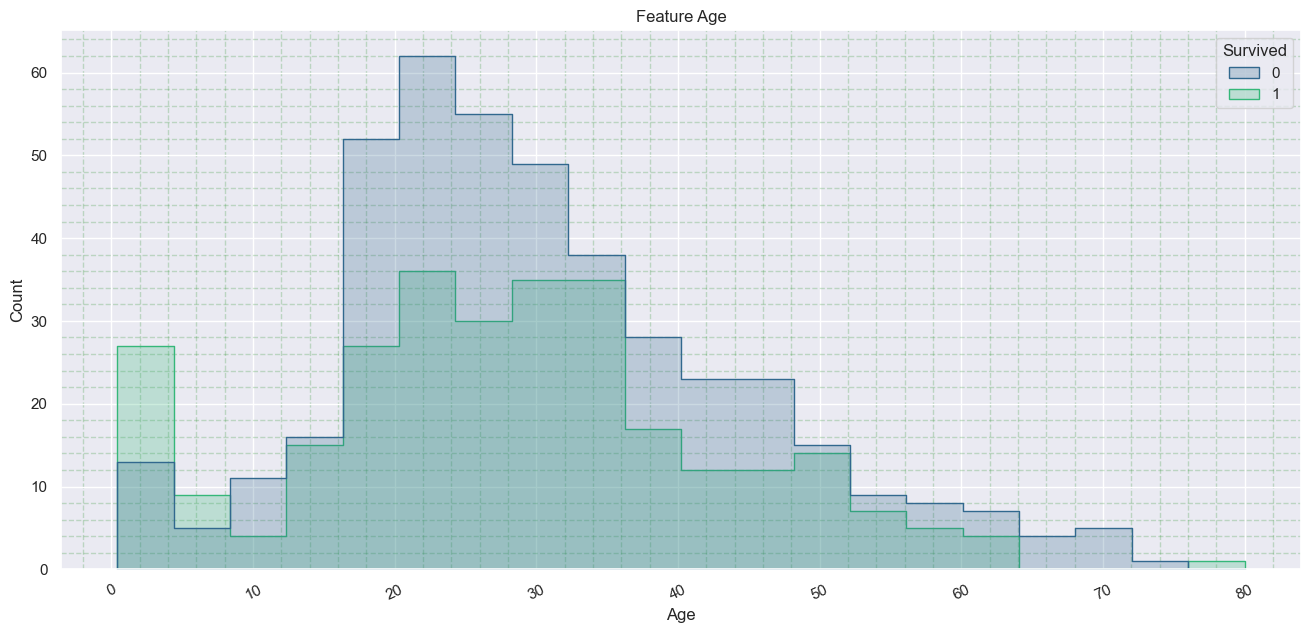

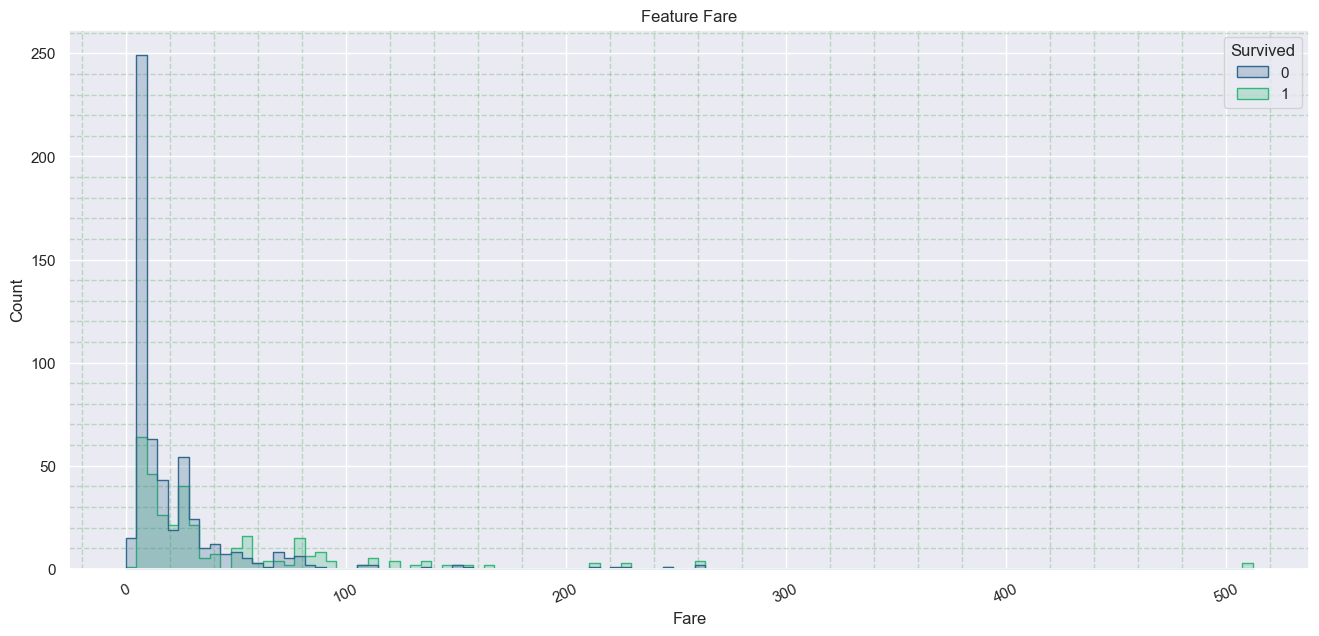

In [12]:
# Plotting the hist for continuous features
for col in train_df.drop(['PassengerId', 'Survived', 'Pclass', 'SibSp', 'Parch'], axis=1).select_dtypes(include='number').columns:
        plt.figure(figsize=(16,7))
        sns.histplot(x=col, data=train_df, hue='Survived', element='step', palette='viridis', legend=True)
        # train_df[col].hist(bins=50)
        plt.grid(True, linestyle='--', color='green', alpha=0.2, which='minor')
        plt.minorticks_on()
        plt.tick_params(which='minor')
        plt.xticks(rotation = 25)
        plt.title(f'Feature {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()

Toddlers (children under 5 years old) were saved in large numbers, consistent with the “Women and Children First” policy.

Notably, the oldest passenger (aged 80) survived.

The highest number of fatalities occurred in the 20–30 age group.

The majority of fatalities had a ticket costing no more than 25.

The passenger with the highest fare survived.

This reflects a class‑based survival advantage: wealthier passengers (typically first class) had better access to lifeboats.

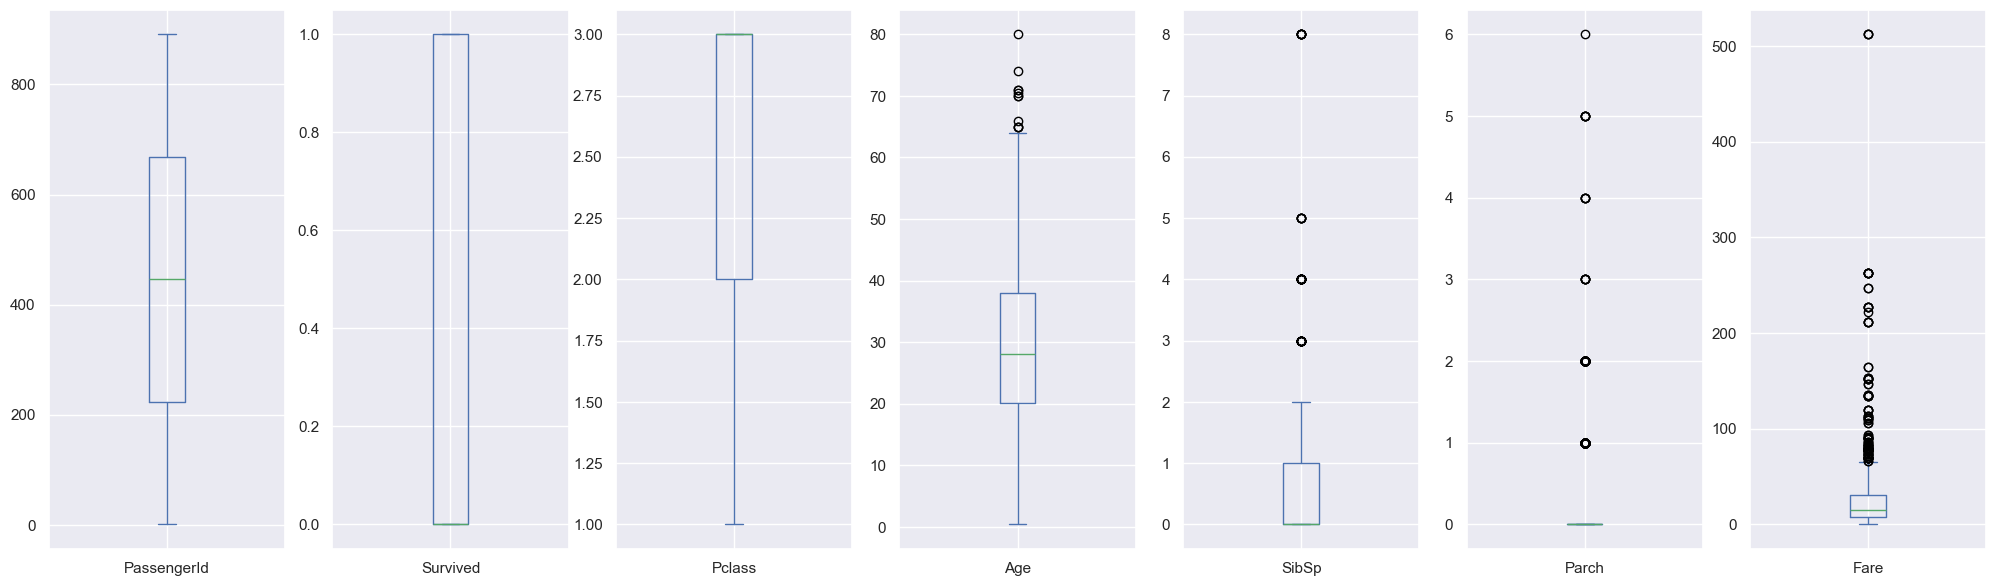

In [13]:
# Plotting the boxplot
train_df.plot(
    kind='box', 
    subplots=True, 
    sharey=False, 
    figsize=(25, 7)
);

Boxplots effectively illustrate the distributions of the previously identified features, including outliers and interquartile ranges.

## Statistical analysis of categorical features

In [14]:
# Visualize missing values
pd.DataFrame(round(train_df.select_dtypes(include='object').isna().mean()*100,),).style.background_gradient('coolwarm')

,0
Name,0.000000
Sex,0.000000
Ticket,0.000000
Cabin,77.000000
Embarked,0.000000


There are a lot of missing values in the feature `Cabin`, we'll work with it later.

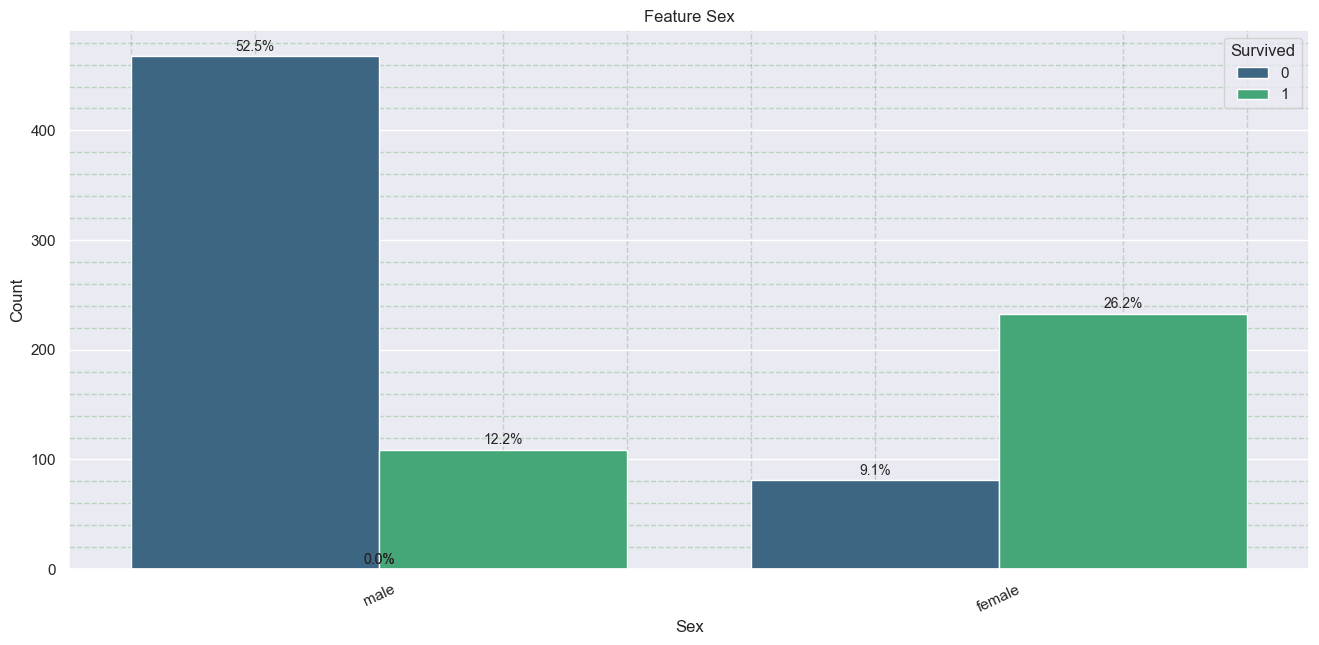

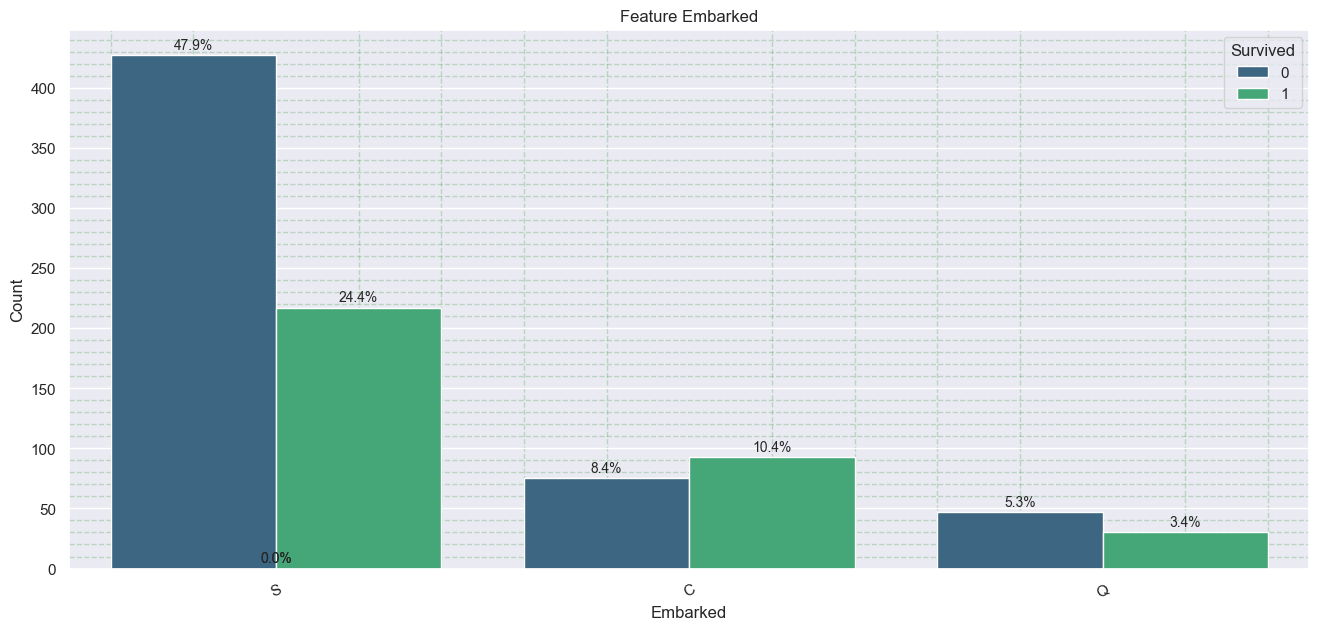

In [15]:
# Plotting the hist for categorical features
for col in train_df.drop(['Name', 'Ticket', 'Cabin'], axis=1).select_dtypes(include=['object']).columns:
    plt.figure(figsize=(16,7))
    ax = sns.countplot(x=col, data=train_df, hue='Survived', palette='viridis', legend=True)
    total = len(train_df)
    for p in ax.patches:
        percentage = 100 * p.get_height() / total
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 5, 
                f'{percentage:.1f}%', ha='center', fontsize=10)
    plt.grid(True, linestyle='--', color='green', alpha=0.2, which='minor')
    plt.minorticks_on()
    plt.tick_params(which='minor')
    plt.xticks(rotation = 25)
    plt.title(f'Feature {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

The gender distribution shows a higher number of male passengers compared to female ones. Men constituted the larger portion of the passenger list, reflecting the typical travel patterns of the era.

However, the survival rate among women was significantly higher, underscoring the “Women and Children First” policy in practice.

Southampton was the embarkation port for the majority of passengers; despite this large cohort, the overall survival rate for Southampton travellers was moderate. In contrast, passengers who embarked at Cherbourg (C) had a notably higher survival rate, with more survivors than non‑survivors in this group.

# Data preprocessing 

## Duplicates

In [16]:
train_df.duplicated().sum()

0

In [17]:
# unique values of categorical features
def cat_unique(df):
    columns = df.select_dtypes(exclude='number').columns.to_list()
    for col in columns:
         display(col, df[col].unique())

In [18]:
cat_unique(train_df)

'Name'

array(['Braund, Mr. Owen Harris',
       'Cumings, Mrs. John Bradley (Florence Briggs Thayer)',
       'Heikkinen, Miss. Laina',
       'Futrelle, Mrs. Jacques Heath (Lily May Peel)',
       'Allen, Mr. William Henry', 'Moran, Mr. James',
       'McCarthy, Mr. Timothy J', 'Palsson, Master. Gosta Leonard',
       'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)',
       'Nasser, Mrs. Nicholas (Adele Achem)',
       'Sandstrom, Miss. Marguerite Rut', 'Bonnell, Miss. Elizabeth',
       'Saundercock, Mr. William Henry', 'Andersson, Mr. Anders Johan',
       'Vestrom, Miss. Hulda Amanda Adolfina',
       'Hewlett, Mrs. (Mary D Kingcome) ', 'Rice, Master. Eugene',
       'Williams, Mr. Charles Eugene',
       'Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)',
       'Masselmani, Mrs. Fatima', 'Fynney, Mr. Joseph J',
       'Beesley, Mr. Lawrence', 'McGowan, Miss. Anna "Annie"',
       'Sloper, Mr. William Thompson', 'Palsson, Miss. Torborg Danira',
       'Asplund, Mrs. Carl Oscar 

'Sex'

array(['male', 'female'], dtype=object)

'Ticket'

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

'Cabin'

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

'Embarked'

array(['S', 'C', 'Q', nan], dtype=object)

## Missing values

In [19]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Age column

In [20]:
def process_initial(df):
    df = df.copy()
    df['Initial'] = df['Name'].str.extract(r'([A-Za-z]+)\.')
    df['Initial'] = df['Initial'].replace(
        ['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer',
         'Col','Rev','Capt','Sir','Don','Dona'],      
        ['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other',
         'Other','Other','Mr','Mr','Mr','Other']   
    )
    return df

In [21]:
# Assigning the NaN values with the ceil values of the mean ages
train_df = process_initial(train_df)
age_means = train_df.groupby('Initial')['Age'].mean()
fare_median = train_df['Fare'].median()
train_df['Age'] = train_df['Age'].fillna(train_df['Initial'].map(age_means))

### Embarked column

In [22]:
embarked_mode = train_df['Embarked'].mode()[0]
train_df['Embarked'] = train_df['Embarked'].fillna(embarked_mode)

## Create new features

In [23]:
# Family Size
train_df["family_size"] = train_df["SibSp"] + train_df["Parch"] + 1
# Number of letters
train_df['vowel_count'] = train_df['Name'].str.count(r'[aeiouAEIOU]')
train_df['consonant_count'] = train_df['Name'].str.count(r'[bcdfghjklmnpqrstvwxyzBCDFGHJKLMNPQRSTVWXYZ]')
# Age bins
# train_df['age_band'] = pd.cut(train_df['Age'], bins=[-np.inf, 16, 32, 48, 64, np.inf], labels=False).astype(int)
# # Fare bins
# train_df['fare_cat'] = pd.qcut(train_df['Fare'], 4, labels=False).astype(int)

## Dropping columns

In [24]:
# Dropping the useless columns
train_df = train_df.drop(['Cabin', 'PassengerId', 'Name', 'Ticket'], axis=1)

## Correlation between the features 

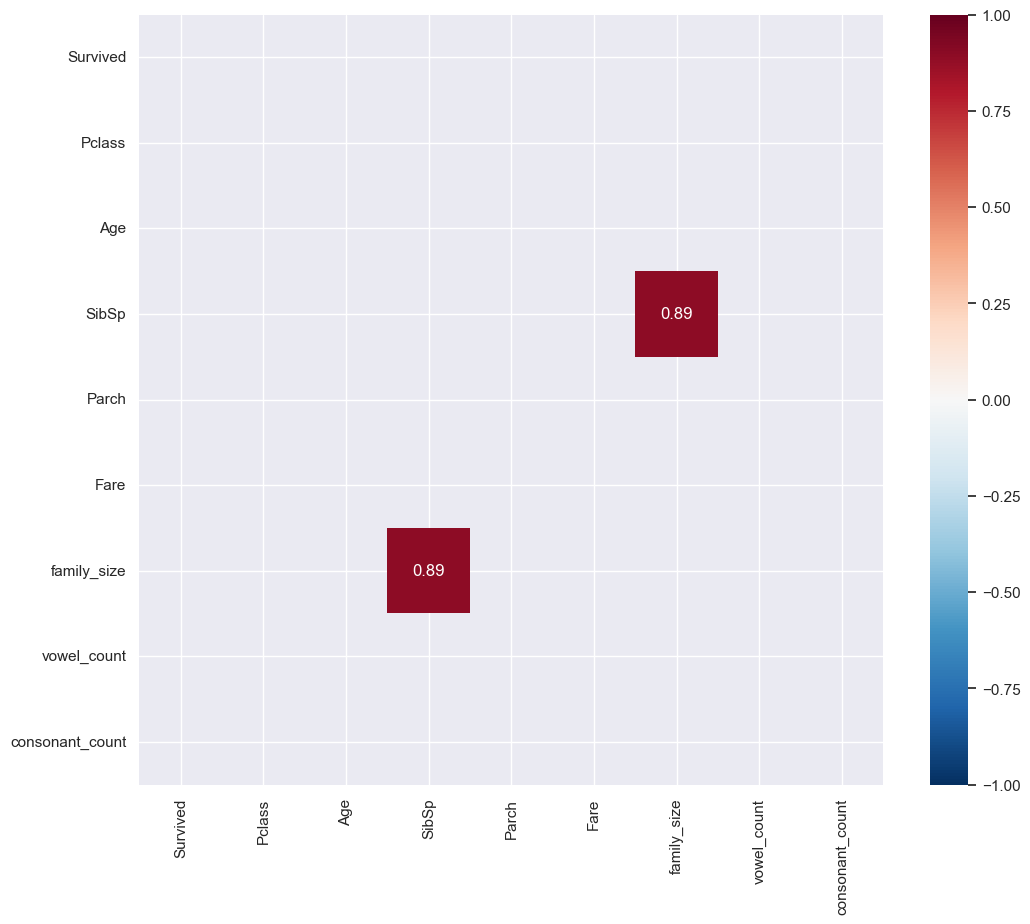

In [27]:
corr = train_df.select_dtypes(include='number').corr()
mask = (np.abs(corr) < 0.8) | np.eye(len(corr), dtype=bool)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1);

We don’t observe multicollinearity, but there are features with strong correlation.

# Modeling 

In [28]:
# Label the data
X_train = train_df.drop('Survived', axis=1)
y_train = train_df['Survived']
print(X_train.shape, y_train.shape)

(891, 11) (891,)


In [29]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Initial,family_size,vowel_count,consonant_count
0,3,male,22.0,1,0,7.2500,S,Mr,2,6,12
1,1,female,38.0,1,0,71.2833,C,Mrs,2,11,30
2,3,female,26.0,0,0,7.9250,S,Miss,1,8,10
3,1,female,35.0,1,0,53.1000,S,Mrs,2,12,22
4,3,male,35.0,0,0,8.0500,S,Mr,1,6,13


In [30]:
# List of columns
ohe_columns = ['Sex', 'Embarked', 'Initial']
num_columns = ['SibSp', 'Parch', 'family_size', 'vowel_count', 'consonant_count', 'Age', 'Fare']
ord_columns = ['Pclass']

# One-Hot Pipeline
ohe_pipe = Pipeline([
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Ordinal Pipeline
ord_pipe = Pipeline([
    ('ord', OrdinalEncoder(categories=[[1, 2, 3]],
                           handle_unknown='use_encoded_value',
                           unknown_value=-1))
])

# Numeric Pipeline
num_pipe = Pipeline([
    ('num', MinMaxScaler())
])

# Preprocessor
data_preprocessor = ColumnTransformer([
    ('ohe', ohe_pipe, ohe_columns),
    ('ord', ord_pipe, ord_columns),
    ('num', num_pipe, num_columns)
], remainder='passthrough').set_output(transform="pandas")

In [31]:
X_train_processed = data_preprocessor.fit_transform(X_train)

X_train_processed.head()

,ohe__Sex_male,ohe__Embarked_Q,ohe__Embarked_S,ohe__Initial_Miss,ohe__Initial_Mr,ohe__Initial_Mrs,ohe__Initial_Other,ord__Pclass,num__SibSp,num__Parch,num__family_size,num__vowel_count,num__consonant_count,num__Age,num__Fare
0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,0.125,0.0,0.1,0.192308,0.212121,0.271174,0.014151
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.125,0.0,0.1,0.384615,0.757576,0.472229,0.139136
2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,0.000,0.0,0.0,0.269231,0.151515,0.321438,0.015469
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.125,0.0,0.1,0.423077,0.515152,0.434531,0.103644
4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,0.000,0.0,0.0,0.192308,0.242424,0.434531,0.015713


In [32]:
# Label the data
print(X_train_processed.shape, y_train.shape)

(891, 15) (891,)


In [34]:
# Search the best estimator
grid_search = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=4000), 
    {'C':np.logspace(-3, 3, 7)},
    cv=5,
    scoring='accuracy',
    n_jobs=1
)
grid_search.fit(X_train_processed, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=4000, random_state=42),
             n_jobs=1,
             param_grid={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])},
             scoring='accuracy')

In [35]:
print('Best model:\n\n', grid_search.best_estimator_,'\n')
print ('Best cross-val metric:', grid_search.best_score_)

Best model:

 LogisticRegression(C=100.0, max_iter=4000, random_state=42) 

Best cross-val metric: 0.8260247316552632
